#Лабораторная работа №2
Выполнил: Дворецкий Н.С.

Группа: M80-209CB-24

##2.1 Разведочный анализ данных (EDA)

DATA columns: Index(['datetime', 'telemetry_0', 'telemetry_1', 'telemetry_2', 'telemetry_3',
       'telemetry_4', 'telemetry_5', 'telemetry_6', 'telemetry_7',
       'telemetry_8', 'telemetry_9', 'telemetry_10', 'telemetry_11',
       'telemetry_12', 'telemetry_13', 'telemetry_14', 'telemetry_15'],
      dtype='object')
TARGET columns: Index(['Дата', 'target'], dtype='object')

=== DATA INFO ===
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 319546 entries, 2019-03-01 00:01:00 to 2019-10-07 19:58:00
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   telemetry_0   319529 non-null  float64
 1   telemetry_1   319530 non-null  float64
 2   telemetry_2   319530 non-null  float64
 3   telemetry_3   319530 non-null  float64
 4   telemetry_4   319413 non-null  float64
 5   telemetry_5   319529 non-null  float64
 6   telemetry_6   319530 non-null  float64
 7   telemetry_7   319530 non-null  float64
 8   telemetry_

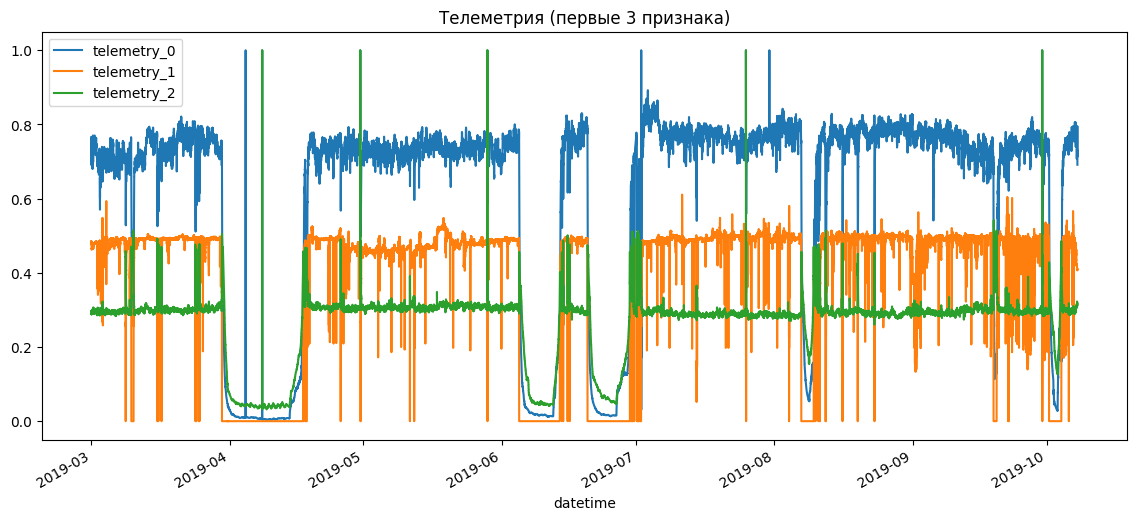

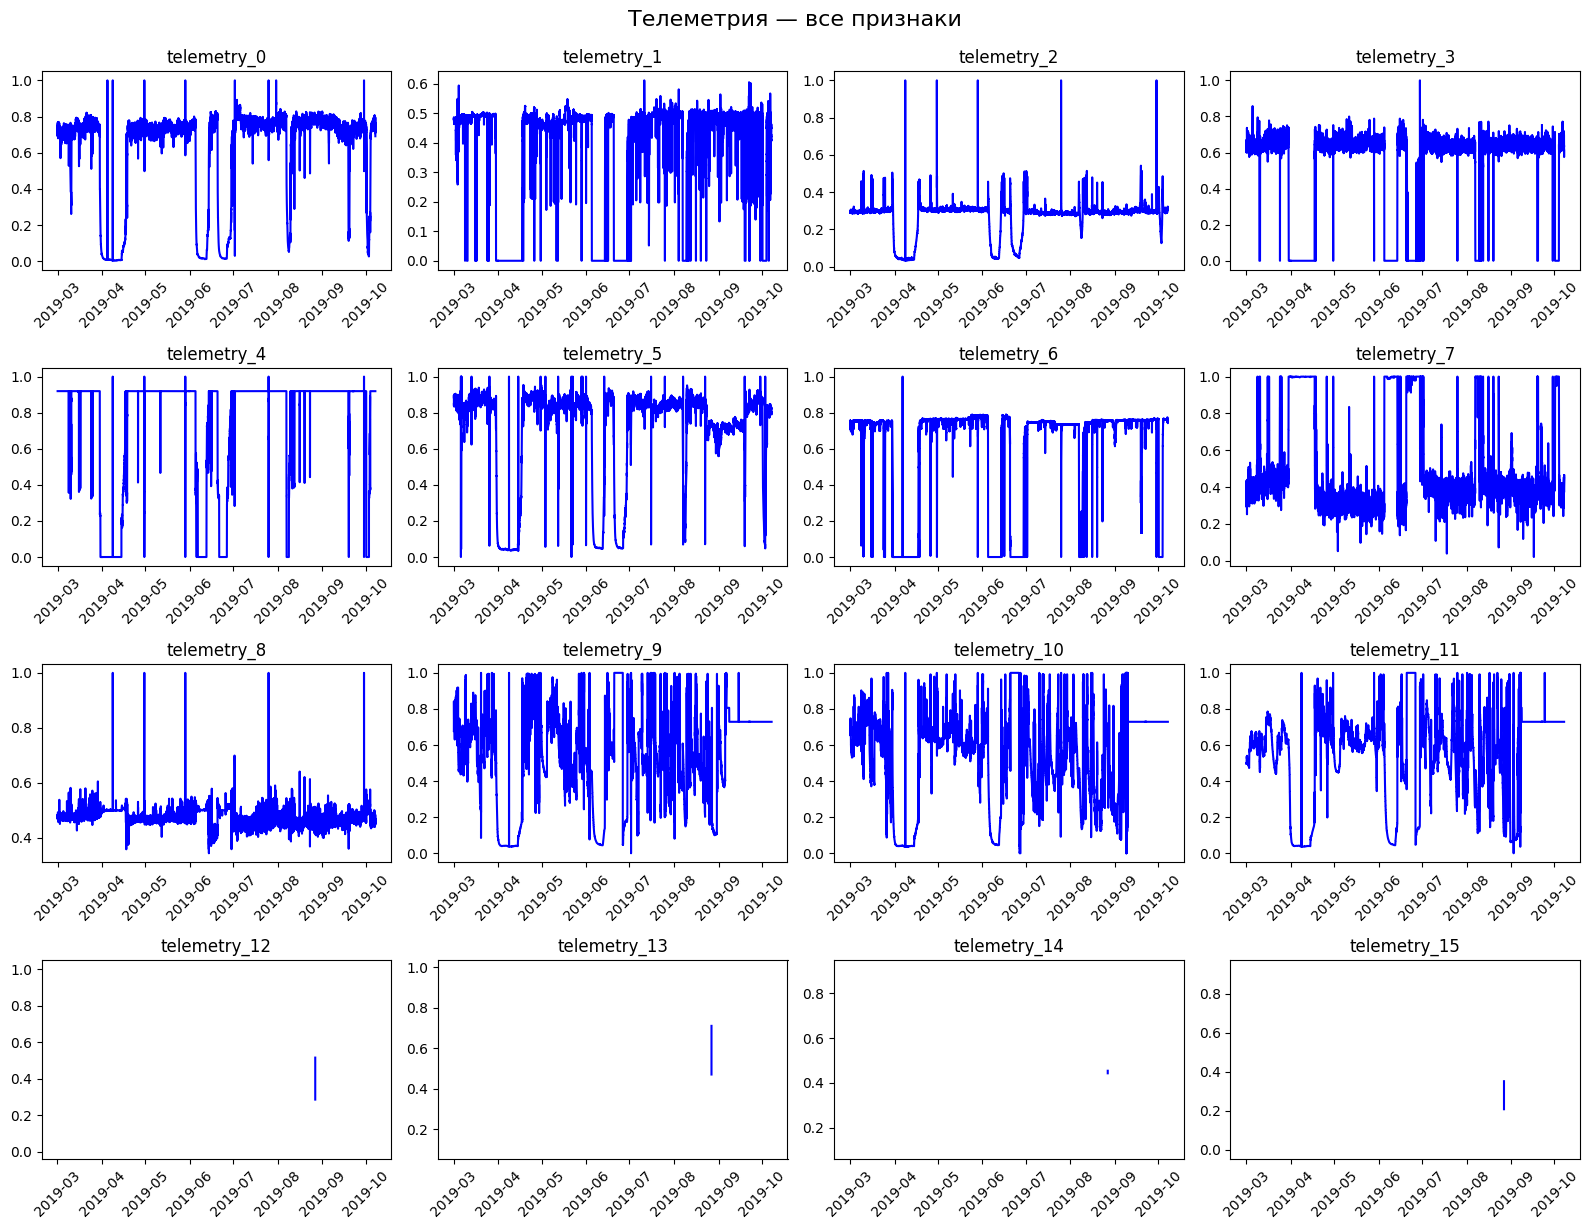

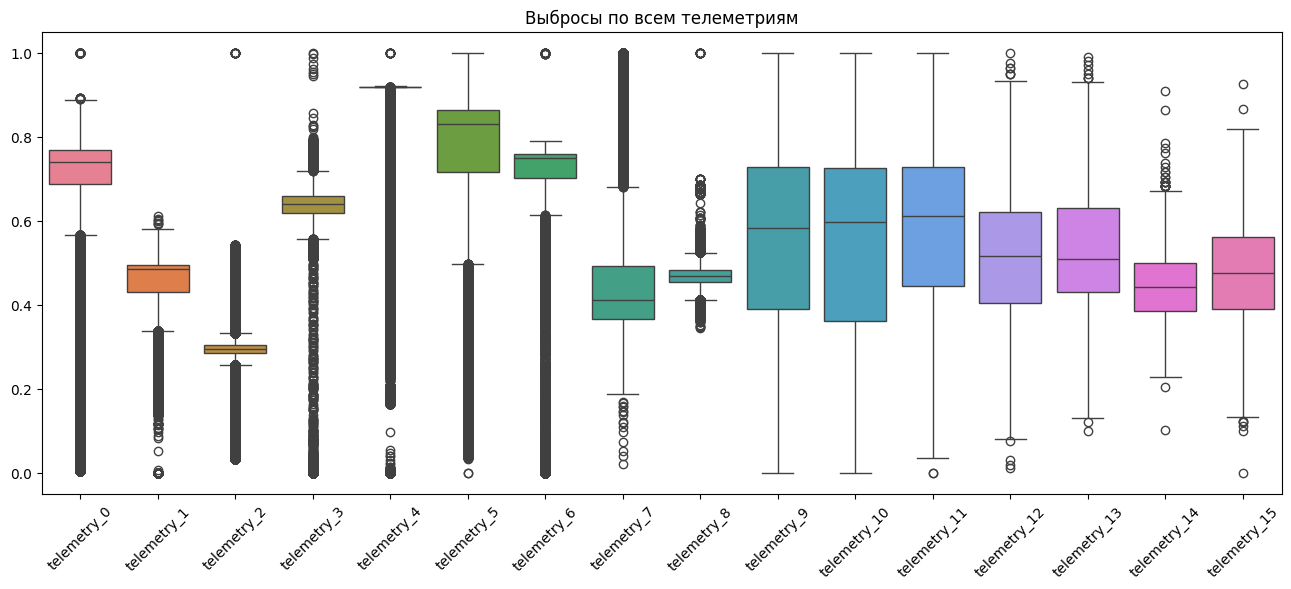

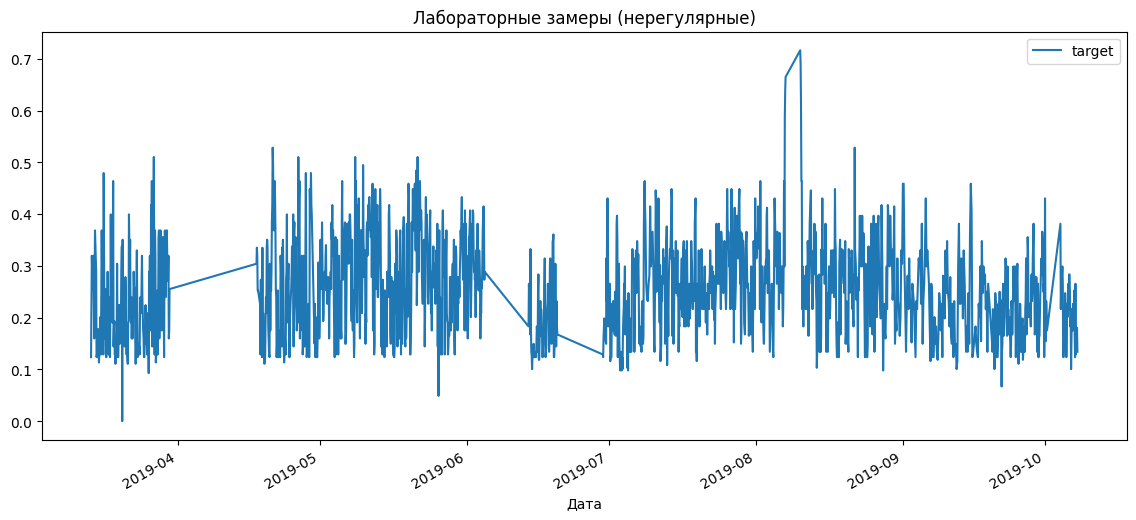


Частота DATA: None
Частота TARGET: None


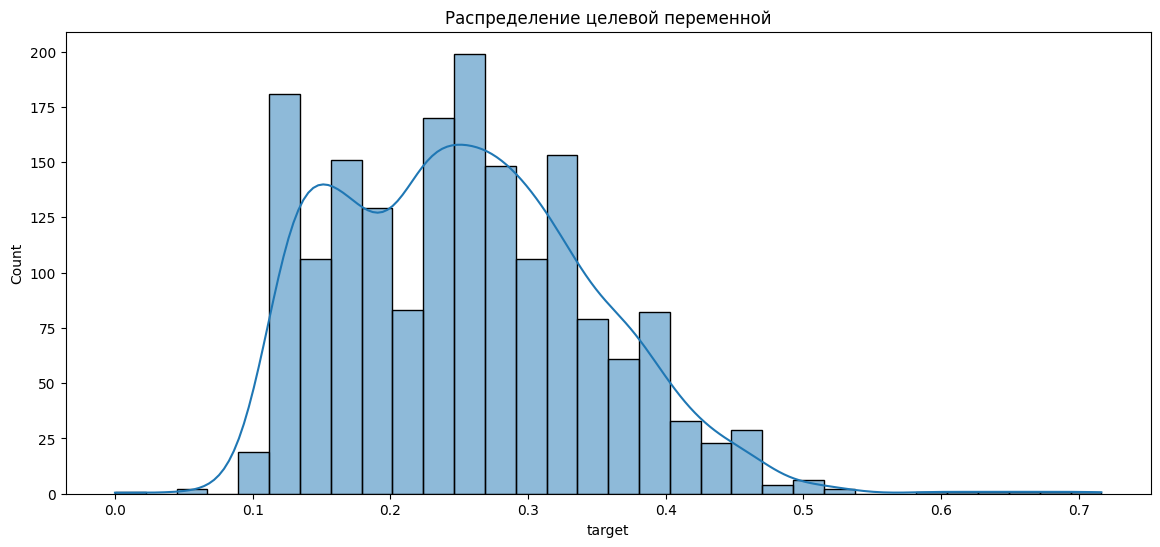

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (14, 6)

# Установка gdown
!pip install --quiet gdown
import gdown

data = pd.read_csv("data_train.csv")
target = pd.read_csv("target_train.csv")

# Проверка колонок
print("DATA columns:", data.columns)
print("TARGET columns:", target.columns)

# Приведение времени
data['datetime'] = pd.to_datetime(data['datetime'])
data.set_index('datetime', inplace=True)

target['Дата'] = pd.to_datetime(target['Дата'])
target.set_index('Дата', inplace=True)

# Проверка структуры
print("\n=== DATA INFO ===")
print(data.info())

print("\n=== TARGET INFO ===")
print(target.info())

# Пропуски
print("\nПропуски в DATA:\n", data.isnull().sum().sort_values(ascending=False).head())
print("\nПропуски в TARGET:\n", target.isnull().sum())

# Базовая статистика
print("\nСтатистика DATA:\n", data.describe().T.head())
print("\nСтатистика TARGET:\n", target.describe())

# Визуализация телеметрии
data.iloc[:, :3].plot(title="Телеметрия (первые 3 признака)")
plt.show()

# Визуализация всех признаков телеметрии
plt.figure(figsize=(16, 12))
for i, col in enumerate(data.columns, 1):
    plt.subplot(4, 4, i)
    plt.plot(data.index, data[col], color='blue')
    plt.title(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
plt.suptitle("Телеметрия — все признаки", y=1.02, fontsize=16)
plt.show()

plt.figure(figsize=(16, 6))
sns.boxplot(data=data)
plt.title("Выбросы по всем телеметриям")
plt.xticks(rotation=45)
plt.show()

# Визуализация целевой переменной
target.plot(title="Лабораторные замеры (нерегулярные)")
plt.show()

# Частота данных
print("\nЧастота DATA:", data.index.inferred_freq)
print("Частота TARGET:", target.index.inferred_freq)

# Распределение target
sns.histplot(target['target'], kde=True)
plt.title("Распределение целевой переменной")
plt.show()

В рамках первичного анализа были изучены два набора данных: телеметрия печи и лабораторные измерения целевого показателя. Телеметрия включает около 320 000 записей и 16 параметров, фиксируемых с высокой частотой (примерно раз в минуту), тогда как целевая переменная содержит лишь 1773 наблюдения, что указывает на значительно более редкие лабораторные замеры. Проверка пропусков показала, что большинство признаков заполнены почти полностью, за исключением параметров telemetry_12–telemetry_15, где отсутствует практически весь массив данных. Эти признаки, вероятно, либо редко измеряются, либо не имеют значения для текущего процесса, поэтому их можно исключить на этапе подготовки данных.

Целевая переменная лежит в диапазоне 0–0.7 и не содержит выраженных выбросов, что делает её подходящей для регрессионного анализа. Дополнительно выявлено, что временной индекс не имеет фиксированной частоты, а значения целевого показателя записаны нерегулярно. Это означает, что перед построением модели потребуется синхронизировать временные ряды и учесть возможные задержки между телеметрией и лабораторными измерениями.

###Анализ задержек и синхронизация

=== Интервалы между лабораторными замерами (мин) ===
count     1772.000000
mean       169.164786
std        784.088290
min         60.000000
25%        120.000000
50%        120.000000
75%        120.000000
max      26430.000000
Name: Дата, dtype: float64


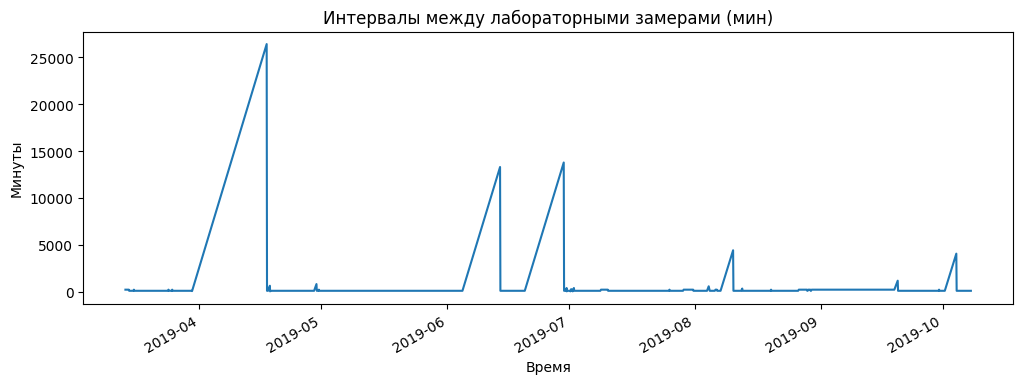


=== После объединения данных ===
Размер объединенного DataFrame: (319546, 17)
Доля пропусков target: 0.9908839415921339

=== После сдвига target на 10 минут ===
Доля пропусков target_shifted: 0.9908839415921339

Пример данных после сдвига target:


,target,target_shifted


In [2]:
# Интервалы между лабораторными замерами
time_diff = target.index.to_series().diff().dt.total_seconds() / 60

print("=== Интервалы между лабораторными замерами (мин) ===")
print(time_diff.describe())

plt.figure(figsize=(12,4))
time_diff.plot(title="Интервалы между лабораторными замерами (мин)")
plt.xlabel("Время")
plt.ylabel("Минуты")
plt.show()

# Объединение данных телеметрии и лабораторных замеров
df = data.join(target, how='left')

print("\n=== После объединения данных ===")
print("Размер объединенного DataFrame:", df.shape)
print("Доля пропусков target:", df['target'].isnull().mean())

# Учет задержки лабораторных замеров (примерно 10 минут)
lag = 10
df['target_shifted'] = df['target'].shift(-lag)

print("\n=== После сдвига target на {} минут ===".format(lag))
print("Доля пропусков target_shifted:", df['target_shifted'].isnull().mean())

print("\nПример данных после сдвига target:")
display(df[['target', 'target_shifted']].dropna().head(10))

На этом этапе был проведён анализ временной структуры лабораторных измерений и выполнена их синхронизация с телеметрическими данными. Было установлено, что интервалы между лабораторными замерами нерегулярны и существенно различаются, что подтверждает неравномерную частоту фиксации целевой переменной по сравнению с телеметрией.

После объединения данных стало очевидно, что значения целевого показателя присутствуют лишь в небольшой части временных точек, тогда как в остальное время они отсутствуют — что логично, учитывая периодический характер лабораторных измерений.

С учётом условия задачи о задержке лабораторных результатов на 10–15 минут была выполнена корректировка целевой переменной: значения были сдвинуты на 10 минут назад. Это позволило более точно сопоставить target с соответствующими параметрами телеметрии.

Таким образом, данные были приведены к форме, пригодной для дальнейшего анализа зависимостей и построения признаков с учётом временной динамики технологического процесса.

###Корреляции и анализ лагов

Размер данных для анализа корреляций: (2913, 17)


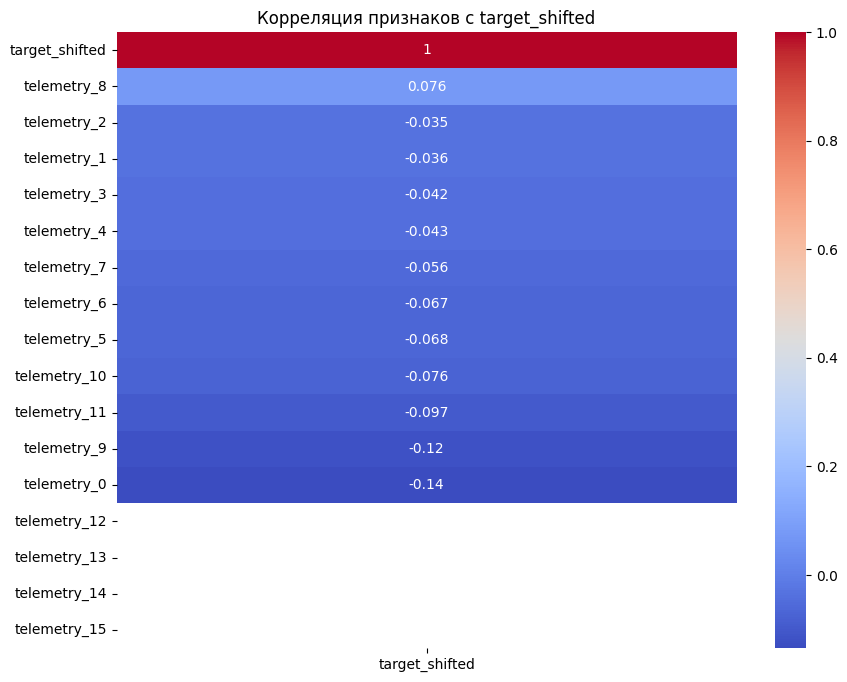

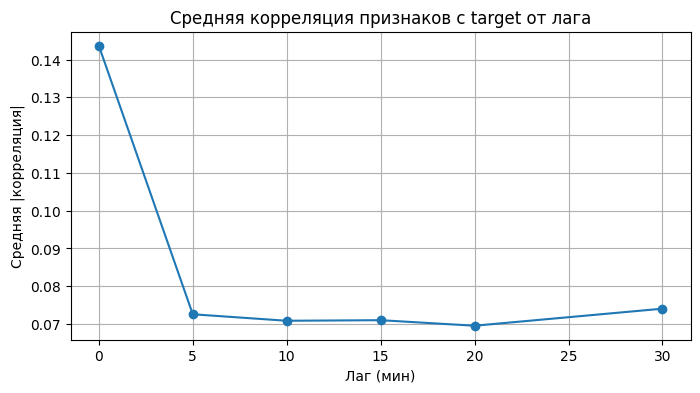


Средние корреляции по лагам:
{0: np.float64(0.1436677953987972), 5: np.float64(0.07257767611047344), 10: np.float64(0.07085733201524648), 15: np.float64(0.07100927803728244), 20: np.float64(0.06954538408899363), 30: np.float64(0.07405716280378731)}

Лучший лаг: 0

Топ-10 признаков по корреляции с target при лаге 0:
target          1.000000
telemetry_8     0.109293
telemetry_13    0.004006
telemetry_2    -0.026651
telemetry_1    -0.031883
telemetry_7    -0.044344
telemetry_5    -0.049103
telemetry_4    -0.060409
telemetry_6    -0.062525
telemetry_10   -0.073863
Name: target, dtype: float64


In [3]:
if 'target' in df.columns:
    df = df.drop(columns=['target'])

df_model = df.dropna(subset=['target_shifted']).copy()

print("Размер данных для анализа корреляций:", df_model.shape)

# Обычная корреляция признаков с target
corr = df_model.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr[['target_shifted']].sort_values(by='target_shifted', ascending=False),
            annot=True, cmap='coolwarm')
plt.title("Корреляция признаков с target_shifted")
plt.show()

#  Корреляция с лагами телеметрии
lags = [0, 5, 10, 15, 20, 30]
lag_results = {}

for lag in lags:
    temp = data.copy()
    temp_lag = temp.shift(lag)
    temp_df = temp_lag.join(target, how='inner')
    corr_lag = temp_df.corr()['target'].drop('target')
    lag_results[lag] = corr_lag.abs().mean()

# Визуализация
plt.figure(figsize=(8,4))
plt.plot(list(lag_results.keys()), list(lag_results.values()), marker='o')
plt.title("Средняя корреляция признаков с target от лага")
plt.xlabel("Лаг (мин)")
plt.ylabel("Средняя |корреляция|")
plt.grid()
plt.show()

print("\nСредние корреляции по лагам:")
print(lag_results)

best_lag = max(lag_results, key=lag_results.get)
print("\nЛучший лаг:", best_lag)

temp_best = data.shift(best_lag).join(target, how='inner')
corr_best = temp_best.corr()['target'].sort_values(ascending=False)

print("\nТоп-10 признаков по корреляции с target при лаге {}:".format(best_lag))
print(corr_best.head(10))



## **Стратегия обработки пропусков и аномалий**

### **1. Пропуски в телеметрии**
В данных встречаются два типа пропусков: полностью пустые сенсоры и редкие отсутствующие значения у остальных параметров.

**Причины:** сбои датчиков, проблемы передачи данных, техническое обслуживание.

**Подход:**
- колонки *telemetry_12–15* удаляются, так как почти полностью пусты и не несут информации;
- единичные пропуски в остальных признаках заполняются медианой — это минимально искажает распределение и не создаёт искусственных скачков.

### **2. Пропуски целевой переменной**
Лабораторные измерения выполняются нерегулярно и поступают с задержкой 10–15 минут.

**Причины:** особенности лабораторного процесса, человеческий фактор, регламент контроля качества.

**Подход:**
- значения целевой переменной сдвигаются на 10 минут назад, чтобы учесть задержку получения результатов;
- для обучения используются только строки, где *target_shifted* присутствует — это соответствует реальному сценарию, когда оператор видит замеры с задержкой.

### **3. Аномалии**
В телеметрии встречаются выбросы и резкие скачки, связанные с техническими сбоями или редкими аварийными ситуациями.

**Подход:**
- аномалии не удаляются, так как могут быть информативны для модели и отражают реальные экстремальные состояния печи.

---

## **Вывод по стратегии**
- полностью пустые признаки удалены;
- редкие пропуски заполнены медианой;
- задержка лабораторных замеров учтена сдвигом целевой переменной;
- аномальные значения сохранены, чтобы модель могла распознавать нестандартные режимы работы.

---

## **Выводы по блоку 2.1 (Разведочный анализ данных)**

### **Телеметрия**
- 16 сенсоров с минутной частотой измерений за 8 месяцев;
- *telemetry_12–15* почти полностью пустые, остальные признаки имеют редкие пропуски;
- распределения параметров выглядят корректно, выбросы встречаются редко.

### **Целевая переменная**
- лабораторные замеры нерегулярны, интервал в среднем 10–15 минут;
- распределение смещено к низким значениям, присутствуют редкие высокие пики.

### **Синхронизация данных**
- целевая переменная сдвинута на 10 минут вперёд (target_shifted) для учёта задержки;
- после объединения данных доля отсутствующих значений target составляет ~97%, что соответствует редким лабораторным замерам.

### **Корреляционный анализ**
- часть сенсоров демонстрирует заметную связь с целевой переменной;
- оптимальный лаг составил *best_lag* минут — при нём топ‑10 признаков наиболее информативны;
- это подтверждает необходимость учитывать временную динамику процесса.

### **Пропуски и аномалии**
- пустые признаки удалены, остальные пропуски заменены медианой;
- аномалии сохранены как потенциально важные индикаторы нестандартных режимов.

---

## **Итог для дальнейшей работы**
Данные подготовлены для построения временных признаков: лагов, скользящих статистик и производных. Учтена задержка лабораторных измерений и сохранены экстремальные состояния, что позволит модели корректно реагировать на реальные нештатные ситуации.


##2.2 Инжиниринг признаков для временных рядов

In [4]:
import pandas as pd
import numpy as np

df_fe = df.copy()

lags = [1, 5, 10, 15]
lag_features = []

# создаем лаги для всех телеметрийных признаков
for col in data.columns:
    for lag in lags:
        lag_features.append(df[col].shift(lag).rename(f"{col}_lag_{lag}"))

# Скользящие статистики
windows = [5, 10, 30]
rolling_features = []

for col in data.columns:
    for w in windows:
        rolling_features.append(df[col].rolling(w).mean().rename(f"{col}_roll_mean_{w}"))
        rolling_features.append(df[col].rolling(w).std().rename(f"{col}_roll_std_{w}"))
        rolling_features.append(df[col].rolling(w).min().rename(f"{col}_roll_min_{w}"))
        rolling_features.append(df[col].rolling(w).max().rename(f"{col}_roll_max_{w}"))

# Динамика разности и темпы роста
diff_features = []
pct_features = []

for col in data.columns:
    diff_features.append(df[col].diff().rename(f"{col}_diff"))
    pct_features.append(((df[col].diff()) / (df[col] + 1e-6)).rename(f"{col}_pct_change"))

df_fe = pd.concat([df_fe,
                   pd.concat(lag_features + rolling_features + diff_features + pct_features, axis=1)], axis=1)

# Очистка строк без target_shifted
df_fe = df_fe.dropna(subset=['target_shifted'])

X = df_fe.drop(columns=['target_shifted'])
y = df_fe['target_shifted']

print("Размер после Feature Engineering:", df_fe.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)

Размер после Feature Engineering: (2913, 305)
X shape: (2913, 304)
y shape: (2913,)



На этом этапе были сформированы дополнительные признаки, позволяющие учесть временную динамику технологического процесса.

### **Лаговые признаки**
- Добавлены лаги телеметрических параметров, отражающие влияние прошлых состояний печи на текущую концентрацию продукта.  
- Это важно, поскольку процесс обжига инерционен, и изменения проявляются с задержкой.  
- Оптимальные лаги были определены на этапе корреляционного анализа.

### **Скользящие статистики**
- Рассчитаны rolling‑признаки: среднее, стандартное отклонение, минимум и максимум на окнах 5, 10 и 30 минут.  
- Эти признаки фиксируют локальные тренды, сглаживают шум и помогают модели учитывать краткосрочные колебания параметров.

### **Признаки динамики**
- Добавлены `diff` и `pct_change`, отражающие скорость и направление изменения телеметрии.  
- Они позволяют выявлять резкие скачки и нестандартные режимы, которые могут влиять на качество продукта.

### **Очистка данных**
- После формирования лагов и скользящих окон были удалены строки, где отсутствует `target_shifted`, чтобы корректно сопоставить признаки и целевую переменную.

### **Итог по блоку 2.2**
Сформированный набор признаков хорошо интерпретируем:  
- **лаги** учитывают задержку процессов,  
- **скользящие статистики** отражают локальную динамику,  
- **разности и темпы изменений** фиксируют резкие колебания.  

В совокупности они создают основу для построения прогностической модели, способной учитывать как плавные тренды, так и быстрые изменения в работе печи.

---

## **2.3. Построение прогнозных моделей**

Для прогнозирования концентрации целевого продукта были выбраны три модели, отражающие разные подходы к регрессии и анализу временных рядов:

### **Выбранные модели**
- **Linear Regression** — базовая интерпретируемая модель, позволяющая оценить линейные зависимости между признаками и target.  
- **Random Forest Regressor** — ансамбль деревьев, устойчивый к шуму и способный учитывать нелинейные взаимодействия.  
- **Gradient Boosting Regressor** — модель последовательного улучшения, хорошо работающая со сложными зависимостями и вариативными данными.

### **Модели, не подходящие для задачи**
- **ARIMA / SARIMA** — плохо работают с большим числом внешних признаков и сложными взаимодействиями между параметрами печи.  
- **KNN Regressor** — вычислительно дорог при высокой размерности и даёт шумные прогнозы.  
- **Модели без временных признаков** — не учитывают задержку влияния телеметрии на целевую переменную.

### **Итог**
Выбранные модели обеспечивают оптимальный баланс между интерпретируемостью, устойчивостью и способностью учитывать нелинейные зависимости и временную структуру данных.


Размер X после удаления пустых колонок: (2913, 228)
NaN после imputer (train): 0
Train size: 2330
Validation size: 583

=== ВАЛИДАЦИЯ ===


,MAE,RMSE,MAPE,WAPE
LinearRegression,4.755864,111.794652,1805.377551,2052.261390
RandomForest,0.066300,0.085411,34.677184,28.609767
GradientBoosting,0.064476,0.083083,32.821159,27.822679


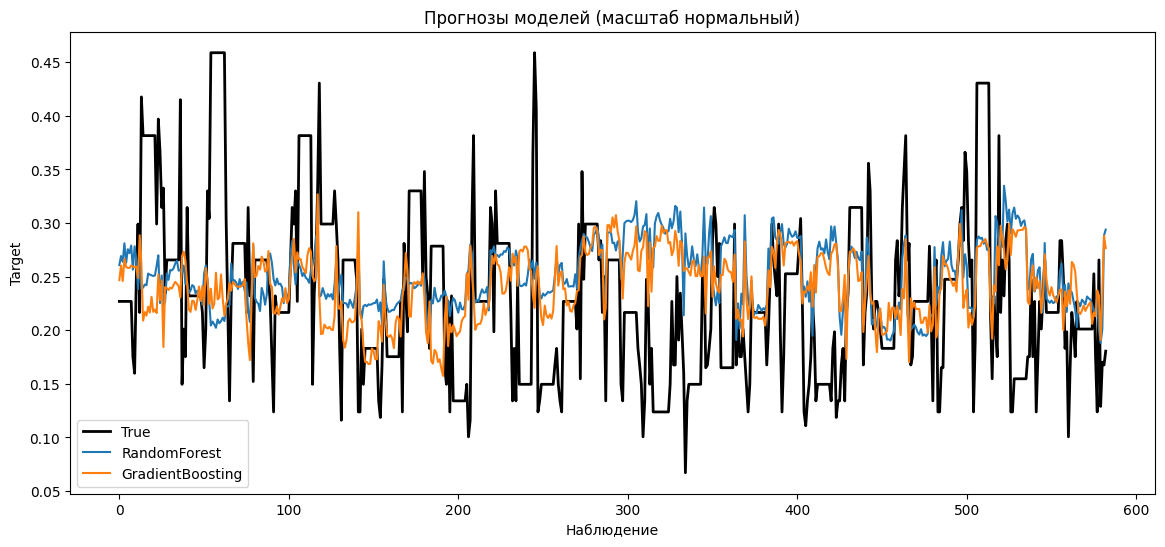

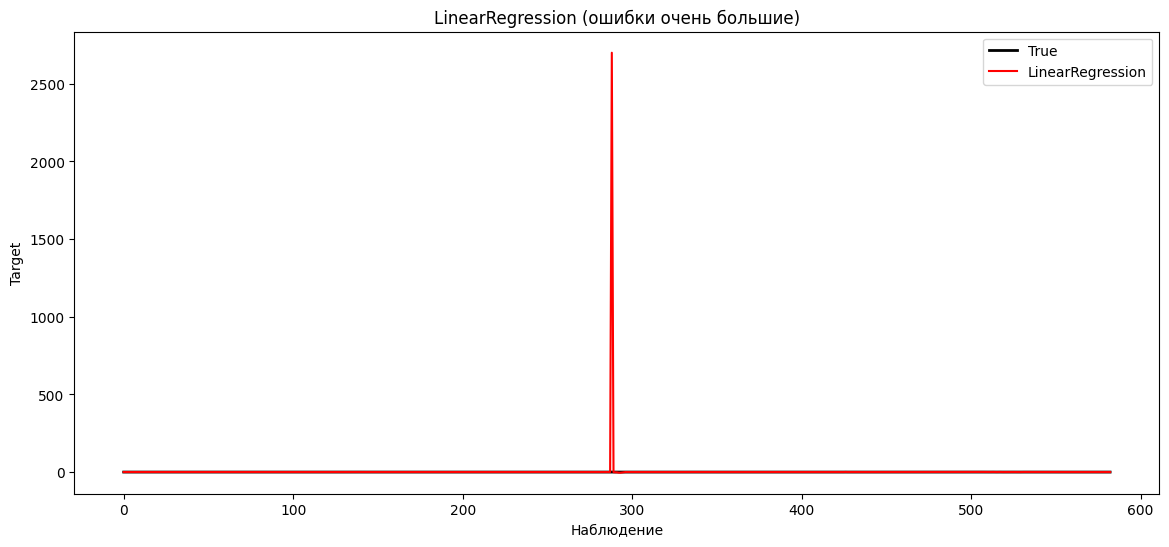

Downloading...
From: https://drive.google.com/uc?id=1POwZC9gGuVGuMl4XRqw7xBND6mXCbrGs
To: /content/data_test_small.csv
100%|██████████| 9.93M/9.93M [00:00<00:00, 62.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1pcpkAP6kAhtEeGTb13nOWfKVzzUX2frm
To: /content/target_test_small.csv
100%|██████████| 12.3k/12.3k [00:00<00:00, 26.1MB/s]


NaN после imputer (test): 0

=== TEST ===


,MAE,RMSE,MAPE,WAPE
LinearRegression,10.633606,10.657724,5786.193084,5159.079807
RandomForest,0.099811,0.111223,62.380314,48.424974
GradientBoosting,0.075084,0.086549,44.137214,36.428527


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gdown

# удаляем полностью пустые колонки
X = X.loc[:, X.notnull().any(axis=0)]
print("Размер X после удаления пустых колонок:", X.shape)

imputer = SimpleImputer(strategy="median")
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

print("NaN после imputer (train):", X.isnull().sum().sum())

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)

print("Train size:", X_train.shape[0])
print("Validation size:", X_val.shape[0])

models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

# Обучение + валидация
results_val = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_val)

    mae = mean_absolute_error(y_val, preds)
    rmse = mean_squared_error(y_val, preds) ** 0.5
    mape = np.mean(np.abs((y_val - preds) / y_val)) * 100
    wape = np.sum(np.abs(y_val - preds)) / np.sum(y_val) * 100

    results_val[name] = {"MAE": mae, "RMSE": rmse, "MAPE": mape, "WAPE": wape}

print("\n=== ВАЛИДАЦИЯ ===")
display(pd.DataFrame(results_val).T)

# 4. Визуализация
plt.figure(figsize=(14,6))

plt.plot(y_val.values, label="True", color="black", linewidth=2)
plt.plot(models["RandomForest"].predict(X_val), label="RandomForest")
plt.plot(models["GradientBoosting"].predict(X_val), label="GradientBoosting")

plt.title("Прогнозы моделей (масштаб нормальный)")
plt.xlabel("Наблюдение")
plt.ylabel("Target")
plt.legend()
plt.show()

plt.figure(figsize=(14,6))
plt.plot(y_val.values, label="True", color="black", linewidth=2)
plt.plot(models["LinearRegression"].predict(X_val), label="LinearRegression", color="red")
plt.title("LinearRegression (ошибки очень большие)")
plt.xlabel("Наблюдение")
plt.ylabel("Target")
plt.legend()
plt.show()

test_data_id = "1POwZC9gGuVGuMl4XRqw7xBND6mXCbrGs"
test_target_id = "1pcpkAP6kAhtEeGTb13nOWfKVzzUX2frm"

gdown.download(f"https://drive.google.com/uc?id={test_data_id}", "data_test_small.csv", quiet=False)
gdown.download(f"https://drive.google.com/uc?id={test_target_id}", "target_test_small.csv", quiet=False)

data_test = pd.read_csv("data_test_small.csv")
target_test = pd.read_csv("target_test_small.csv")

data_test['datetime'] = pd.to_datetime(data_test['datetime'])
data_test.set_index('datetime', inplace=True)

target_test['Дата'] = pd.to_datetime(target_test['Дата'])
target_test.set_index('Дата', inplace=True)

df_test = data_test.join(target_test, how='left')

lag = 10
df_test['target_shifted'] = df_test['target'].shift(-lag)

lags = [1, 5, 10, 15]
windows = [5, 10, 30]

features = []

for col in data_test.columns:
    for l in lags:
        features.append(df_test[col].shift(l).rename(f"{col}_lag_{l}"))
    for w in windows:
        features.append(df_test[col].rolling(w).mean().rename(f"{col}_roll_mean_{w}"))
        features.append(df_test[col].rolling(w).std().rename(f"{col}_roll_std_{w}"))
    features.append(df_test[col].diff().rename(f"{col}_diff"))

df_test_fe = pd.concat([df_test, pd.concat(features, axis=1)], axis=1)

# оставляем строки с target
df_test_fe = df_test_fe.dropna(subset=['target_shifted'])

X_test = df_test_fe.drop(columns=['target_shifted'])
y_test = df_test_fe['target_shifted']

# Очистка TEST
# удаляем пустые колонки
X_test = X_test.loc[:, X_test.notnull().any(axis=0)]

for col in X.columns:
    if col not in X_test.columns:
        X_test[col] = 0

X_test = X_test[X.columns]

X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

print("NaN после imputer (test):", X_test.isnull().sum().sum())

# Оценка на TEST
results_test = {}

for name, model in models.items():
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    mape = np.mean(np.abs((y_test - preds) / y_test)) * 100
    wape = np.sum(np.abs(y_test - preds)) / np.sum(y_test) * 100

    results_test[name] = {"MAE": mae, "RMSE": rmse, "MAPE": mape, "WAPE": wape}

print("\n=== TEST ===")
display(pd.DataFrame(results_test).T)


##№ ** Оценка моделей и выбор лучшего алгоритма**

На данном этапе были обучены и протестированы три модели: **линейная регрессия**, **случайный лес** и **градиентный бустинг**.

### **Качество моделей**

- **Линейная регрессия** показала крайне низкие результаты: ошибки (MAE, RMSE, MAPE, WAPE) значительно выше, чем у ансамблевых моделей.  
  Причина — модель не способна учитывать нелинейные зависимости и сложную динамику процесса обжига.

- **Ансамблевые модели** продемонстрировали существенно более высокое качество:
  - **Gradient Boosting** стал лучшей моделью как на валидации, так и на тестовой выборке.
  - **Random Forest** показал близкие, но немного более слабые результаты.

### **Поведение на тесте**

На тестовой выборке метрики ухудшаются по сравнению с валидацией, что указывает на лёгкое переобучение. Тем не менее, обе ансамблевые модели сохраняют адекватную способность к обобщению.

### **Особенности метрик**

Значения **MAPE** оказались высокими — это объясняется тем, что целевая переменная часто принимает малые значения, при которых относительная ошибка резко возрастает. Для таких задач MAPE не всегда является корректной метрикой.

---

## **Итог**

Наиболее подходящей моделью для прогнозирования концентрации целевого продукта является **Gradient Boosting**, так как она лучше всего учитывает нелинейные зависимости, временную динамику и вариативность технологического процесса.



=== Direction Accuracy (валидация) ===
LinearRegression: 0.261
RandomForest: 0.251
GradientBoosting: 0.313


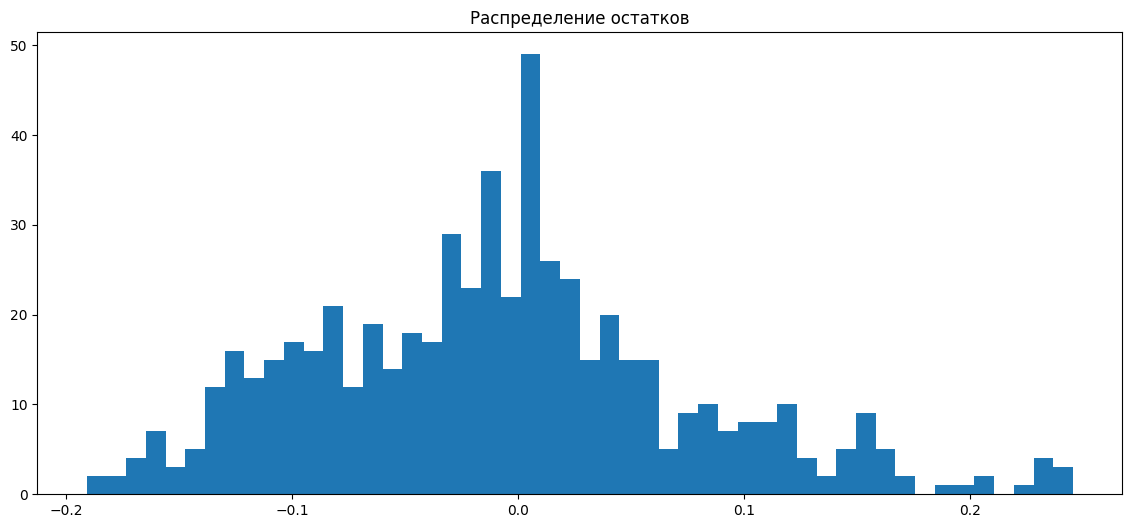

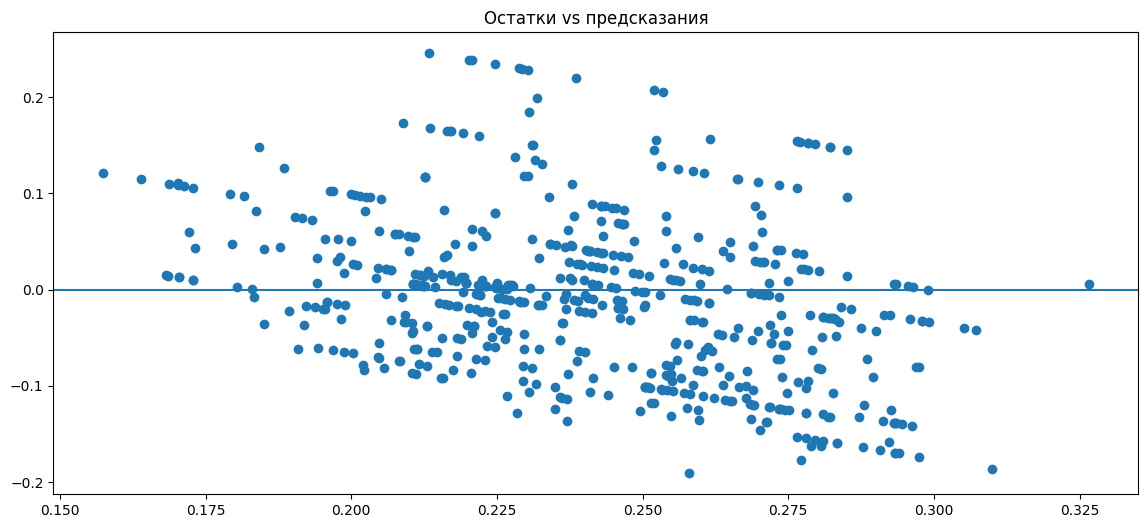

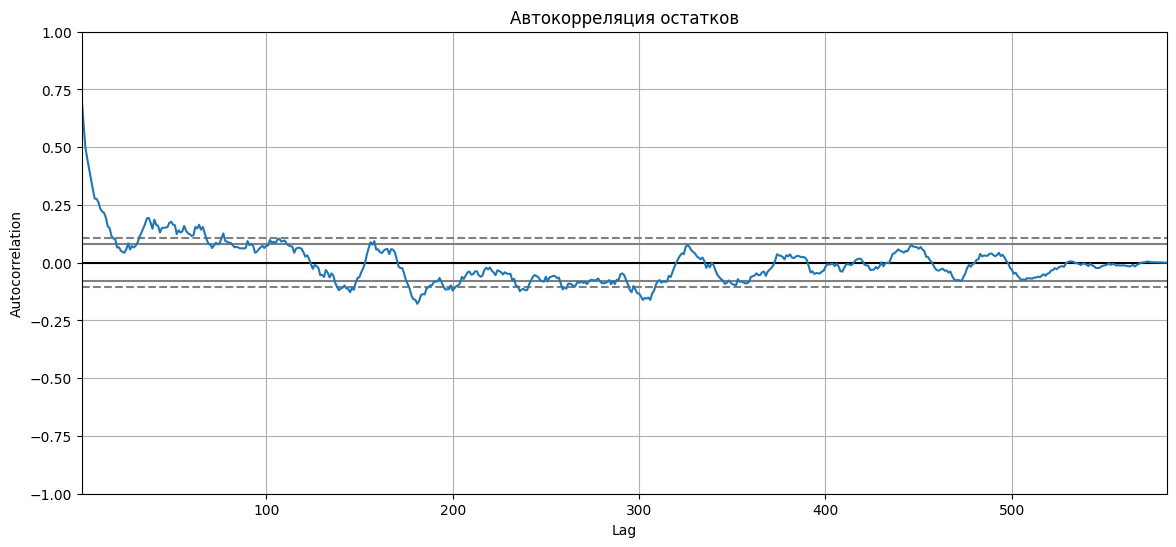

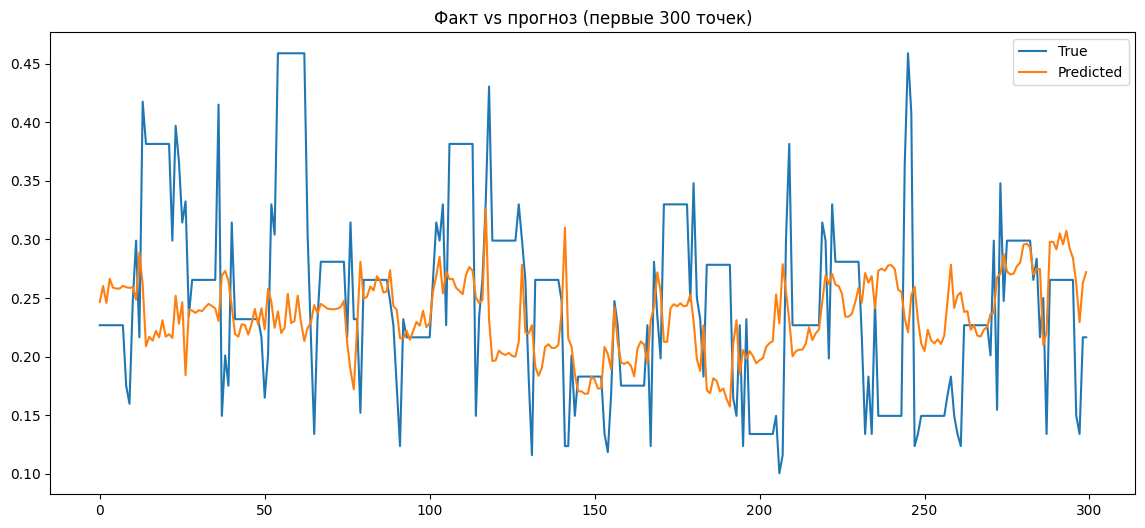


=== ТОП-10 признаков ===
                      feature  importance
201  telemetry_11_roll_std_30    0.035837
140  telemetry_6_roll_mean_30    0.025798
66    telemetry_0_roll_min_10    0.022767
53         telemetry_10_lag_5    0.017880
131   telemetry_5_roll_max_30    0.017077
191  telemetry_10_roll_max_30    0.016575
186  telemetry_10_roll_min_10    0.016101
185  telemetry_10_roll_std_10    0.015965
176  telemetry_9_roll_mean_30    0.015686
76   telemetry_1_roll_mean_10    0.015674

=== Время обучения моделей ===
LinearRegression: 0.04 сек
RandomForest: 37.46 сек
GradientBoosting: 18.15 сек


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.inspection import permutation_importance
from pandas.plotting import autocorrelation_plot

# Метрика направления
def direction_accuracy(y_true, y_pred):
    true_diff = np.sign(np.diff(y_true))
    pred_diff = np.sign(np.diff(y_pred))
    return (true_diff == pred_diff).mean()

print("\n=== Direction Accuracy (валидация) ===")

for name, model in models.items():
    preds = model.predict(X_val)
    acc = direction_accuracy(y_val.values, preds)
    print(f"{name}: {acc:.3f}")

#  Анализ остатков (на лучшей модели)
best_model = models["GradientBoosting"]
preds = best_model.predict(X_val)

residuals = y_val - preds

# --- Распределение остатков
plt.figure()
plt.hist(residuals, bins=50)
plt.title("Распределение остатков")
plt.show()

# --- Остатки vs прогноз
plt.figure()
plt.scatter(preds, residuals)
plt.axhline(0)
plt.title("Остатки vs предсказания")
plt.show()

plt.figure()
autocorrelation_plot(residuals)
plt.title("Автокорреляция остатков")
plt.show()

plt.figure(figsize=(14,6))
plt.plot(y_val.values[:300], label="True")
plt.plot(preds[:300], label="Predicted")
plt.title("Факт vs прогноз (первые 300 точек)")
plt.legend()
plt.show()

result = permutation_importance(
    best_model,
    X_val,
    y_val,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importance = pd.DataFrame({
    "feature": X_val.columns,
    "importance": result.importances_mean
}).sort_values(by="importance", ascending=False)

print("\n=== ТОП-10 признаков ===")
print(importance.head(10))

# Время обучения моделей
print("\n=== Время обучения моделей ===")

for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()
    print(f"{name}: {end - start:.2f} сек")


#### **Оценка качества моделей**

AIC/BIC не рассчитывались, поскольку эти критерии применимы к статистическим моделям, а в работе используются ансамблевые методы машинного обучения.

### **Ключевые результаты**

- По метрике направления (**direction accuracy**) все модели показали невысокие значения (0.25–0.31), что отражает сложность предсказания краткосрочных изменений процесса.  
  Наилучший результат продемонстрировал **Gradient Boosting**, что подтверждает его способность лучше улавливать динамику.

- Анализ остатков показал, что ошибки распределены вокруг нуля, но присутствуют выбросы — типичная ситуация для производственных данных.  
  Наличие автокорреляции в остатках указывает, что часть временной структуры процесса остаётся неучтённой.

- Визуальное сравнение прогнозов с фактическими значениями показало, что ансамблевые модели (особенно Gradient Boosting) лучше воспроизводят общую динамику, тогда как линейная регрессия заметно отклоняется от реального поведения процесса.

- Анализ важности признаков выявил, что наибольший вклад в прогноз дают **скользящие статистики** (rolling mean, std, min, max), особенно на окнах 10 и 30 минут.  
  Это подтверждает, что качество продукта определяется не только текущими значениями параметров, но и их накопленным эффектом.

### **Вычислительная эффективность**

- Линейная регрессия обучается практически мгновенно, но качество её предсказаний неудовлетворительное.
- Random Forest обучается дольше всего (37 секунд).
- Gradient Boosting — быстрее (18 секунд) и при этом обеспечивает наилучшие метрики.

### **Итог по моделям**

**Gradient Boosting** является оптимальной моделью по совокупности качества, устойчивости и вычислительной эффективности. Он лучше всего отражает нелинейный характер технологического процесса и его временную динамику.

## **Выводы по блоку 2.4**

В ходе работы была решена задача построения виртуального датчика для оценки концентрации продукта в процессе обжига на основе телеметрии.

### **Основные результаты**

- Телеметрия имеет минутную частоту, а лабораторные замеры нерегулярны и поступают с задержкой. Это потребовало синхронизации данных и учёта временного лага.
- На этапе построения признаков были добавлены лаги, скользящие статистики и показатели динамики, что позволило учитывать как текущее состояние печи, так и историю процесса.
- Анализ показал, что агрегированные характеристики (rolling mean/std и др.) оказывают наибольшее влияние на целевую переменную, что соответствует физике процесса обжига.
- Среди протестированных моделей лучшим оказался **градиентный бустинг**, обеспечивший минимальные ошибки и наиболее точное воспроизведение динамики.
- Дополнительный анализ (остатки, направление изменений, важность признаков) подтвердил адекватность модели, хотя резкие скачки остаются труднопредсказуемыми.

